In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("netflix1.csv")
print("✅ Loaded dataset:", df.shape)

✅ Loaded dataset: (8790, 10)


Cleaning Done ✅ (8787, 15)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,movie_minutes,tv_seasons,added_year,added_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,90.0,NaN,2021,9
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,NaN,1.0,2021,9
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,NaN,1.0,2021,9
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,91.0,NaN,2021,9
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,125.0,NaN,2021,9


In [ ]:
# -------------------------
# A) Missing Values BEFORE cleaning
# -------------------------
print("\n🔎 Missing values BEFORE cleaning:")
print(df.isna().sum())

# -------------------------
# B) Cleaning steps
# -------------------------

# 1) Convert "Not Given" to NaN (treat as missing)
df.replace("Not Given", np.nan, inplace=True)

# 2) Remove duplicates (ignore show_id)
cols_without_id = [c for c in df.columns if c != "show_id"]
df = df.drop_duplicates(subset=cols_without_id, keep="first")

# 3) Convert date_added to datetime
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# 4) Ensure release_year is numeric
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")

# 5) Create numeric duration value + separate movie minutes / tv seasons
df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype("Int64")
df["movie_minutes"] = np.where(df["type"] == "Movie", df["duration_value"], pd.NA)
df["tv_seasons"]   = np.where(df["type"] == "TV Show", df["duration_value"], pd.NA)

# 6) Optional: year/month from date_added (helps in trend charts)
df["added_year"]  = df["date_added"].dt.year.astype("Int64")
df["added_month"] = df["date_added"].dt.month.astype("Int64")

# -------------------------
# C) Missing Values AFTER cleaning
# -------------------------
print("\n✅ Missing values AFTER cleaning:")
print(df.isna().sum())

# Quick final check
print("\n✅ Final dataset shape:", df.shape)
df.head()


🔎 Missing values BEFORE cleaning:
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

✅ Missing values AFTER cleaning:
show_id              0
type                 0
title                0
director          2587
country            287
date_added           0
release_year         0
rating               0
duration             0
listed_in            0
duration_value       0
movie_minutes     2663
tv_seasons        6124
added_year           0
added_month          0
dtype: int64

✅ Final dataset shape: (8787, 15)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,movie_minutes,tv_seasons,added_year,added_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,90,<NA>,2021,9
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,<NA>,1,2021,9
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,<NA>,1,2021,9
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,91,<NA>,2021,9
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,125,<NA>,2021,9


In [ ]:
# EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#This prints a clean KPI summary for report/dashboard

total_titles = len(df)
movies = (df["type"] == "Movie").sum()
tvshows = (df["type"] == "TV Show").sum()
unique_countries = df["country"].dropna().str.split(", ").explode().nunique()
unique_genres = df["listed_in"].dropna().str.split(", ").explode().nunique()
latest_added = df["date_added"].max().date()

kpis = {
    "Total Titles": total_titles,
    "Movies": movies,
    "TV Shows": tvshows,
    "Unique Countries": unique_countries,
    "Unique Genres": unique_genres,
    "Latest Added Date": str(latest_added)
}

kpis

{'Total Titles': 8787,
 'Movies': np.int64(6124),
 'TV Shows': np.int64(2663),
 'Unique Countries': 85,
 'Unique Genres': 42,
 'Latest Added Date': '2021-09-25'}

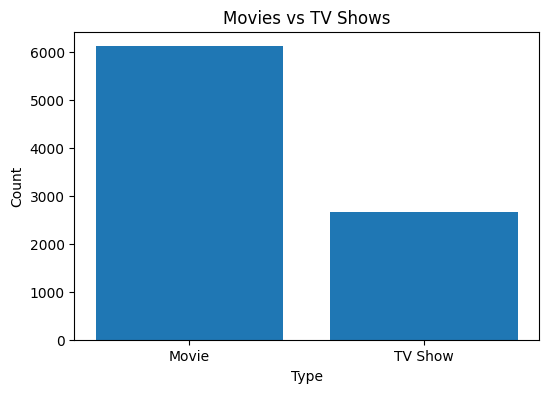

In [ ]:
#Movies vs TV Shows (Bar)
type_counts = df["type"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values)
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

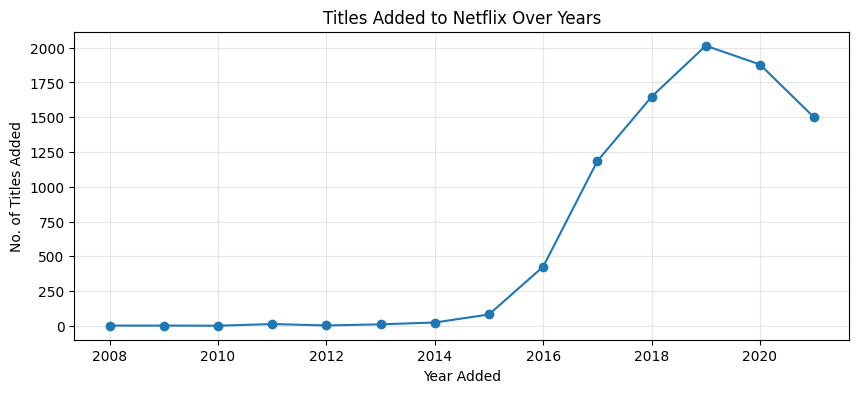

In [ ]:
#Content Added Over Years (Trend)
yearly_added = df.groupby("added_year").size().sort_index()

plt.figure(figsize=(10,4))
plt.plot(yearly_added.index, yearly_added.values, marker="o")
plt.title("Titles Added to Netflix Over Years")
plt.xlabel("Year Added")
plt.ylabel("No. of Titles Added")
plt.grid(True, alpha=0.3)
plt.show()

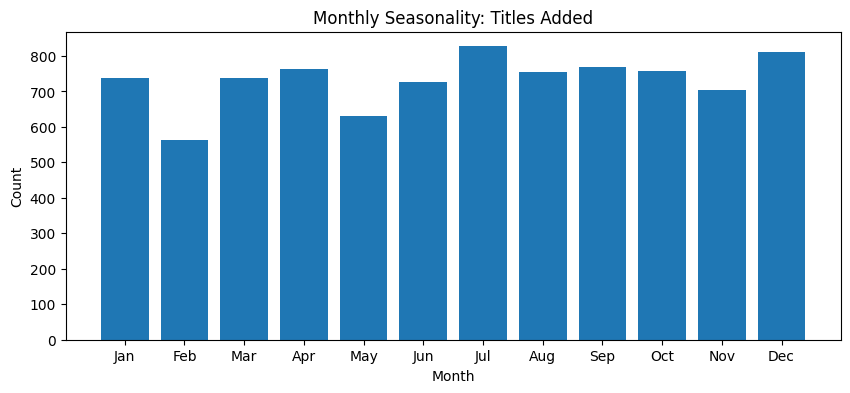

In [ ]:
#Monthly Seasonality
month_added = df.groupby("added_month").size().sort_index()
month_names = ["","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(10,4))
plt.bar([month_names[i] for i in month_added.index], month_added.values)
plt.title("Monthly Seasonality: Titles Added")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

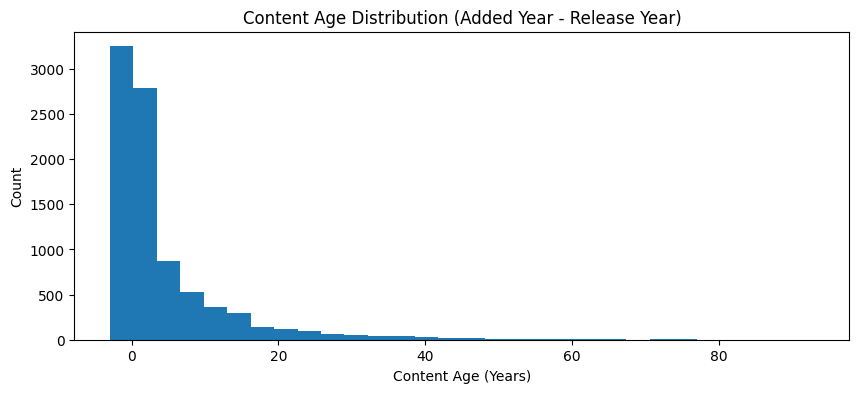

In [ ]:
#How old is content when Netflix adds it?” (Content Age)
df["content_age"] = df["added_year"] - df["release_year"]

plt.figure(figsize=(10,4))
plt.hist(df["content_age"].dropna(), bins=30)
plt.title("Content Age Distribution (Added Year - Release Year)")
plt.xlabel("Content Age (Years)")
plt.ylabel("Count")
plt.show()

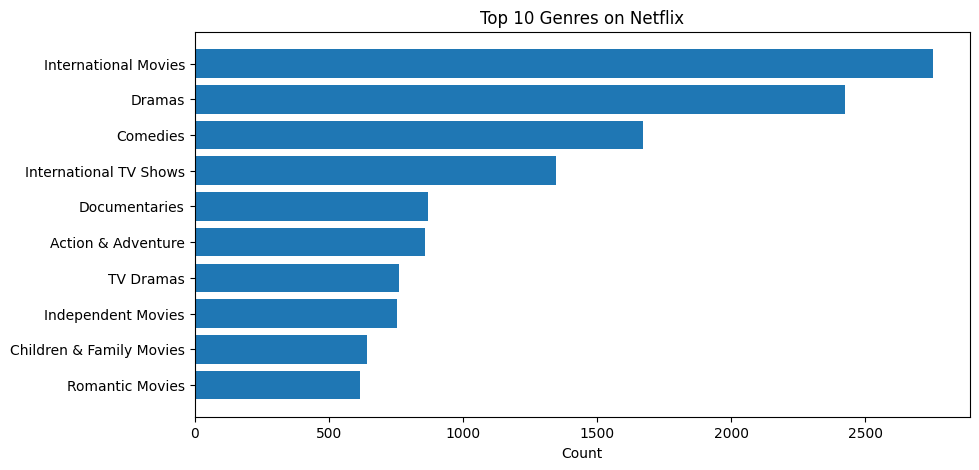

In [ ]:
#Top 10 Genres
genre_exploded = df.copy()
genre_exploded["genre"] = genre_exploded["listed_in"].str.split(", ")
genre_exploded = genre_exploded.explode("genre")

top_genres = genre_exploded["genre"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.barh(top_genres.index[::-1], top_genres.values[::-1])
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.show()

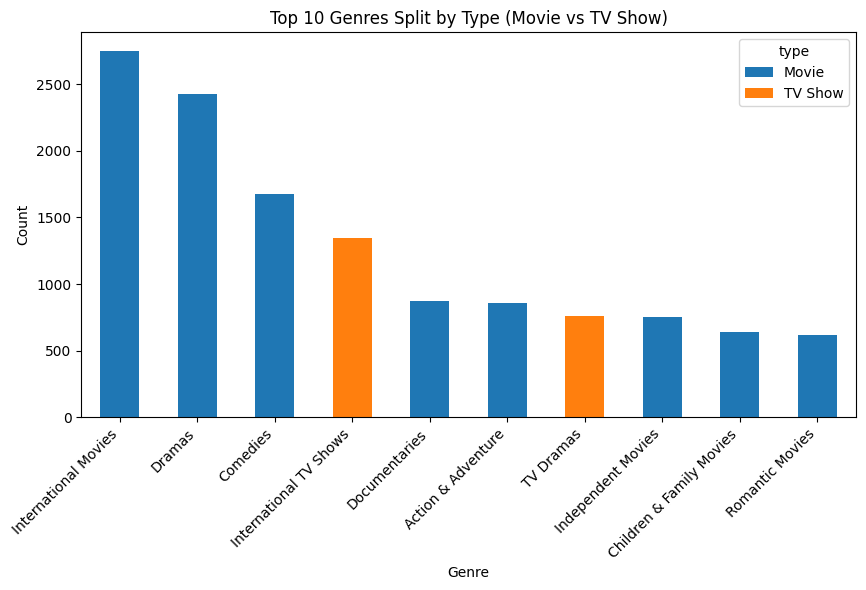

In [ ]:
#Top Genres split by Type (Stacked Bar)
top10_genre_names = top_genres.index.tolist()

g = genre_exploded[genre_exploded["genre"].isin(top10_genre_names)]
pivot = pd.crosstab(g["genre"], g["type"]).loc[top10_genre_names]

pivot.plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Top 10 Genres Split by Type (Movie vs TV Show)")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

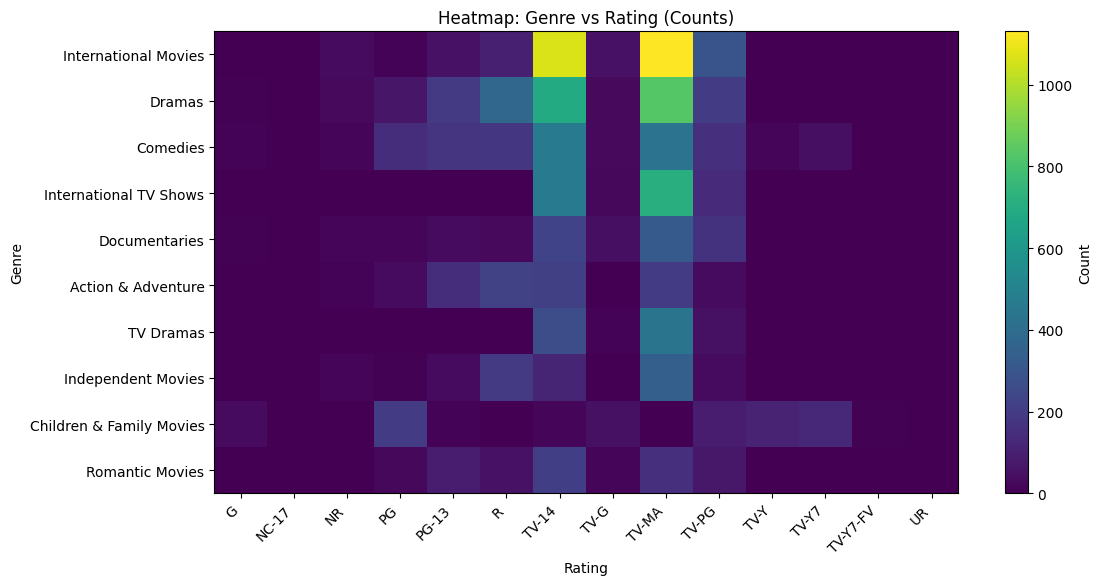

In [ ]:
#Genre × Rating Heatmap
# Use top 10 genres only so heatmap looks clean
g2 = genre_exploded[genre_exploded["genre"].isin(top10_genre_names)].copy()

heat = pd.crosstab(g2["genre"], g2["rating"])
heat = heat.loc[top10_genre_names]  # keep order

plt.figure(figsize=(12,6))
plt.imshow(heat.values, aspect="auto")
plt.title("Heatmap: Genre vs Rating (Counts)")
plt.xlabel("Rating")
plt.ylabel("Genre")
plt.xticks(ticks=range(len(heat.columns)), labels=heat.columns, rotation=45, ha="right")
plt.yticks(ticks=range(len(heat.index)), labels=heat.index)
plt.colorbar(label="Count")
plt.show()

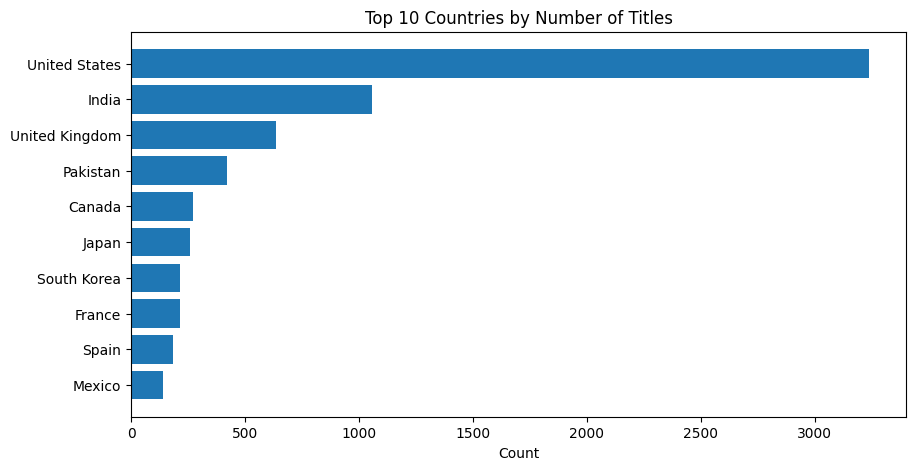

In [ ]:
#Top 10 Countries
country_exploded = df.copy()
country_exploded["country_one"] = country_exploded["country"].str.split(", ")
country_exploded = country_exploded.explode("country_one")

top_countries = country_exploded["country_one"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.barh(top_countries.index[::-1], top_countries.values[::-1])
plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Count")
plt.show()

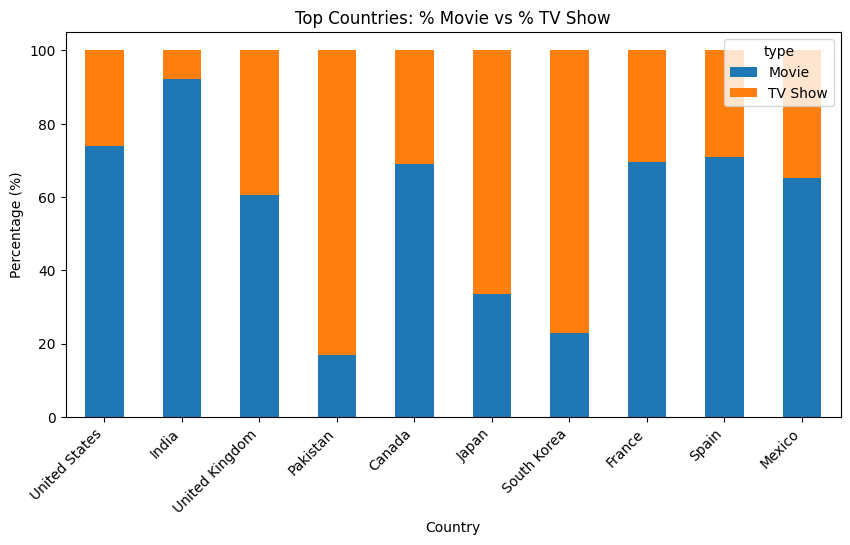

In [ ]:
#Top Countries — % Movies vs % TV Shows (100% stacked)
top10_country_names = top_countries.index.tolist()
c = country_exploded[country_exploded["country_one"].isin(top10_country_names)]

ct = pd.crosstab(c["country_one"], c["type"]).loc[top10_country_names]
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

ct_percent.plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Top Countries: % Movie vs % TV Show")
plt.xlabel("Country")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

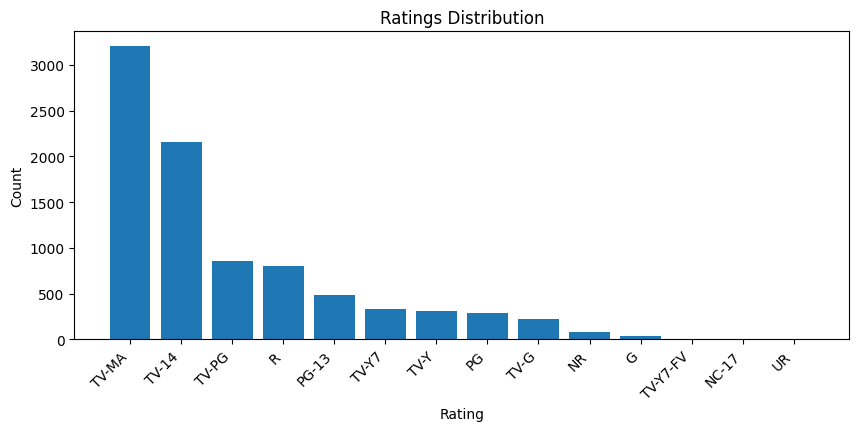

In [ ]:
#Rating Distribution
rating_counts = df["rating"].value_counts()

plt.figure(figsize=(10,4))
plt.bar(rating_counts.index, rating_counts.values)
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

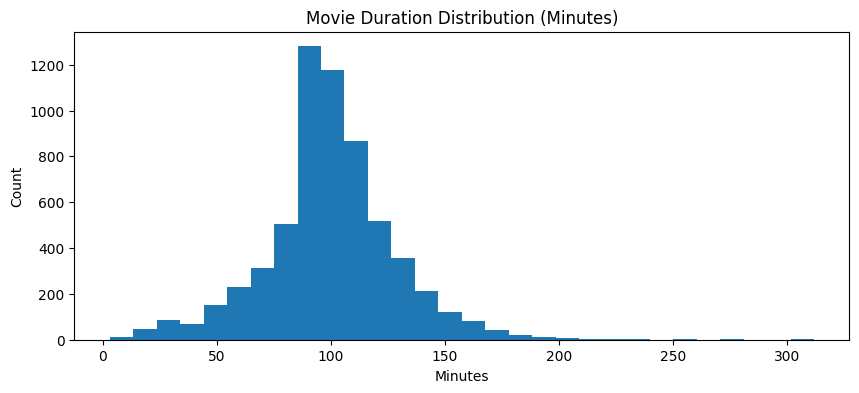

In [ ]:
# Duration: Movies (Minutes) + TV Shows (Seasons)
#Movies: minutes distribution
plt.figure(figsize=(10,4))
plt.hist(df["movie_minutes"].dropna(), bins=30)
plt.title("Movie Duration Distribution (Minutes)")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()

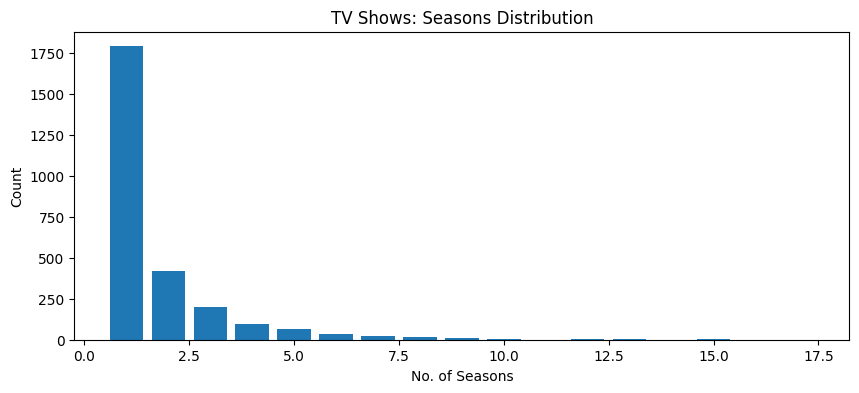

In [ ]:
#TV Shows: seasons distribution
tv_season_counts = df["tv_seasons"].dropna().value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.bar(tv_season_counts.index.astype(int), tv_season_counts.values)
plt.title("TV Shows: Seasons Distribution")
plt.xlabel("No. of Seasons")
plt.ylabel("Count")
plt.show()

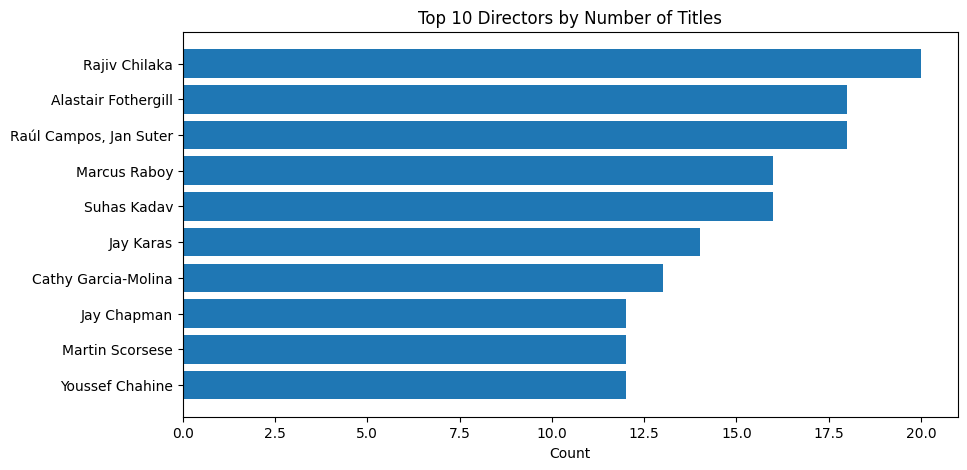

In [ ]:
#Top 10 Directors
top_directors = df["director"].dropna().value_counts().head(10)

plt.figure(figsize=(10,5))
plt.barh(top_directors.index[::-1], top_directors.values[::-1])
plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Count")
plt.show()

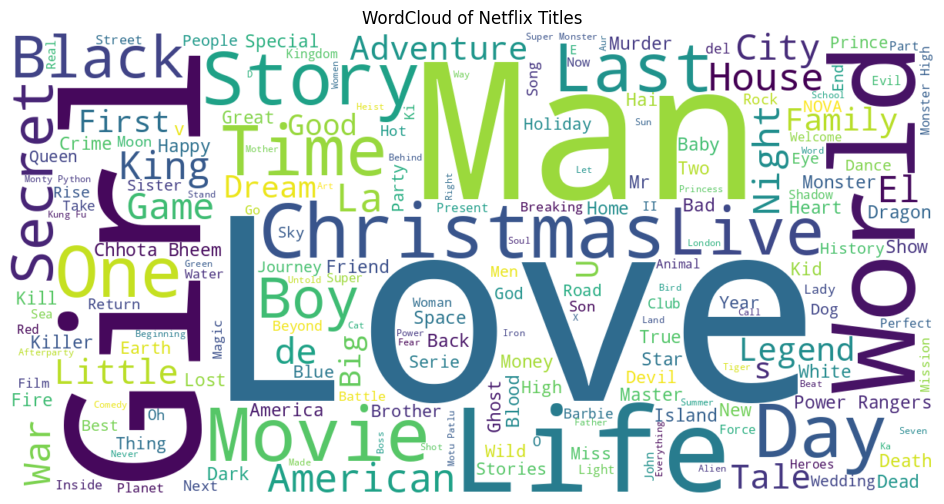

In [ ]:
#WordCloud
!pip -q install wordcloud
from wordcloud import WordCloud

titles_text = " ".join(df["title"].dropna().astype(str).tolist())

wc = WordCloud(width=1200, height=600, background_color="white").generate(titles_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Netflix Titles")
plt.show()

In [ ]:
# Helper tables
genre_exploded = df.assign(genre=df["listed_in"].str.split(", ")).explode("genre")
country_exploded = df.assign(country_one=df["country"].str.split(", ")).explode("country_one")

top_genres = genre_exploded["genre"].value_counts().head(5)
top_countries = country_exploded["country_one"].value_counts().head(5)
yearly_added = df.groupby("added_year").size().sort_index()
rating_counts = df["rating"].value_counts()

insights = []

insights.append(f"Netflix catalog contains {len(df)} titles, dominated by Movies ({(df['type']=='Movie').sum()}) compared to TV Shows ({(df['type']=='TV Show').sum()}).")
insights.append(f"Director information is missing for {df['director'].isna().sum()} titles, while country is missing for {df['country'].isna().sum()} titles after converting 'Not Given' to NaN.")
insights.append(f"The most common rating is '{rating_counts.idxmax()}', indicating the platform strongly targets that maturity segment.")
insights.append(f"Top genres include: " + ", ".join([f"{g} ({c})" for g,c in top_genres.items()]) + ".")
insights.append(f"Top contributing countries are: " + ", ".join([f"{c} ({n})" for c,n in top_countries.items()]) + ".")
insights.append(f"Netflix added maximum titles in {int(yearly_added.idxmax())}, highlighting a peak expansion period.")
insights.append(f"Monthly seasonality shows the highest additions in month {int(df.groupby('added_month').size().idxmax())}, suggesting content release clustering during that period.")

# Duration insights
avg_movie = df["movie_minutes"].dropna().astype(float).mean()
common_seasons = df["tv_seasons"].dropna().astype(int).mode()[0]
insights.append(f"Average movie duration is ~{avg_movie:.1f} minutes, indicating standard feature-length content.")
insights.append(f"Most TV shows have {common_seasons} season(s), showing strong dominance of limited/short series content.")

# Content age insight
df["content_age"] = df["added_year"] - df["release_year"]
median_age = df["content_age"].dropna().median()
insights.append(f"Median content age at time of addition is {int(median_age)} years, meaning Netflix frequently adds relatively recent content alongside older classics.")

# Print nicely
for i, s in enumerate(insights, 1):
    print(f"{i}. {s}")

1. Netflix catalog contains 8787 titles, dominated by Movies (6124) compared to TV Shows (2663).
2. Director information is missing for 2587 titles, while country is missing for 287 titles after converting 'Not Given' to NaN.
3. The most common rating is 'TV-MA', indicating the platform strongly targets that maturity segment.
4. Top genres include: International Movies (2752), Dramas (2424), Comedies (1673), International TV Shows (1348), Documentaries (869).
5. Top contributing countries are: United States (3240), India (1056), United Kingdom (638), Pakistan (420), Canada (271).
6. Netflix added maximum titles in 2019, highlighting a peak expansion period.
7. Monthly seasonality shows the highest additions in month 7, suggesting content release clustering during that period.
8. Average movie duration is ~99.6 minutes, indicating standard feature-length content.
9. Most TV shows have 1 season(s), showing strong dominance of limited/short series content.
10. Median content age at time o

In [ ]:
#K-Means Clustering Model
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---- A) Select features for clustering ----
X = df[["listed_in", "rating", "country", "duration_value", "release_year", "added_year"]].copy()

# Fill missing (because we converted "Not Given" -> NaN)
X["listed_in"] = X["listed_in"].fillna("")
X["rating"] = X["rating"].fillna("Unknown")
X["country"] = X["country"].fillna("Unknown")

# ---- B) Preprocessing (Text + Categorical + Numeric) ----
preprocess = ColumnTransformer(
    transformers=[
        ("genres_tfidf", TfidfVectorizer(stop_words="english"), "listed_in"),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["rating", "country"]),
        ("num", StandardScaler(), ["duration_value", "release_year", "added_year"])
    ],
    remainder="drop"
)

# ---- C) Pick best K quickly (silhouette) ----
best_k, best_score = None, -1
for k in range(2, 9):  # 2 to 8 is enough for internship project
    pipe = Pipeline([("prep", preprocess), ("kmeans", KMeans(n_clusters=k, random_state=42, n_init=10))])
    labels = pipe.fit_predict(X)
    score = silhouette_score(pipe.named_steps["prep"].transform(X), labels)
    if score > best_score:
        best_k, best_score = k, score

print(f"✅ Best K selected: {best_k}  |  Silhouette Score: {best_score:.4f}")

# ---- D) Final model with best K ----
kmeans_model = Pipeline([
    ("prep", preprocess),
    ("kmeans", KMeans(n_clusters=best_k, random_state=42, n_init=10))
])

df["cluster"] = kmeans_model.fit_predict(X)

print("\n✅ Clustering Done!")
print("Cluster counts:\n", df["cluster"].value_counts().sort_index())
df[["title","type","listed_in","rating","country","cluster"]].head()

✅ Best K selected: 3  |  Silhouette Score: 0.2029

✅ Clustering Done!
Cluster counts:
 cluster
0    2858
1    5281
2     648
Name: count, dtype: int64


,title,type,listed_in,rating,country,cluster
0,Dick Johnson Is Dead,Movie,Documentaries,PG-13,United States,1
1,Ganglands,TV Show,"Crime TV Shows, International TV Shows, TV Act...",TV-MA,France,0
2,Midnight Mass,TV Show,"TV Dramas, TV Horror, TV Mysteries",TV-MA,United States,0
3,Confessions of an Invisible Girl,Movie,"Children & Family Movies, Comedies",TV-PG,Brazil,1
4,Sankofa,Movie,"Dramas, Independent Movies, International Movies",TV-MA,United States,2


In [ ]:
# Top genres per cluster (easy interpretation)
tmp = df[["cluster","listed_in"]].copy()
tmp["genre"] = tmp["listed_in"].str.split(", ")
tmp = tmp.explode("genre")

top_genres_cluster = (tmp.groupby("cluster")["genre"]
                      .value_counts()
                      .groupby(level=0).head(3)
                      .reset_index(name="count"))

top_genres_cluster

,cluster,genre,count
0,0,International TV Shows,1345
1,0,TV Dramas,757
2,0,TV Comedies,565
3,1,International Movies,2523
4,1,Dramas,2139
5,1,Comedies,1424
6,2,Dramas,265
7,2,Comedies,211
8,2,International Movies,198


In [ ]:
#Predict Cluster + Show Sample Titles

#User enters values → model returns the cluster segment + example titles from that segment.
def predict_cluster(listed_in, rating, country, duration_value, release_year, added_year):
    custom = pd.DataFrame([{
        "listed_in": listed_in,
        "rating": rating,
        "country": country,
        "duration_value": duration_value,
        "release_year": release_year,
        "added_year": added_year
    }])

    cluster_id = int(kmeans_model.predict(custom)[0])
    print(f"🎯 Predicted Cluster: {cluster_id}")

    # Show 5 example titles from same cluster (looks impressive)
    examples = df[df["cluster"] == cluster_id][["title","type","listed_in","rating","country"]].head(5)
    print("\n📌 Sample titles from this cluster:")
    display(examples)

# ✅ Example run (you can change values)
predict_cluster(
    listed_in="Dramas, International Movies",
    rating="TV-MA",
    country="India",
    duration_value=120,
    release_year=2020,
    added_year=2021
)

🎯 Predicted Cluster: 1

📌 Sample titles from this cluster:


,title,type,listed_in,rating,country
0,Dick Johnson Is Dead,Movie,Documentaries,PG-13,United States
3,Confessions of an Invisible Girl,Movie,"Children & Family Movies, Comedies",TV-PG,Brazil
6,The Starling,Movie,"Comedies, Dramas",PG-13,United States
7,Motu Patlu in the Game of Zones,Movie,"Children & Family Movies, Comedies, Music & Mu...",TV-Y7,India
8,Je Suis Karl,Movie,"Dramas, International Movies",TV-MA,Germany
